<a href="https://colab.research.google.com/github/Ashik-13/PINNs/blob/main/1D_Poisson_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Define the Neural Network

In [ ]:
def create_model():

    model = {
        'dense1': tf.keras.layers.Dense( 50, activation='tanh'),

        'dense2': tf.keras.layers.Dense( 50,activation='tanh'),

        'dense3': tf.keras.layers.Dense( 50, activation='tanh'),

        'output_layer': tf.keras.layers.Dense( 1 )
    }

    return model

# Define Forward Pass

In [ ]:
def call_model(model, x):

    x = model['dense1'](x)

    x = model['dense2'](x)

    x = model['dense3'](x)

    x = model['output_layer'](x)

    return x

Set up a network and test it

In [ ]:
model = create_model()

x_example = tf.constant(
    [[0.5]],
    dtype=tf.float32
)

y_example = call_model(model, x_example)

print("Input x =", x_example.numpy())
print("Initial NN prediction =", y_example.numpy())

Input x = [[0.5]]
Initial NN prediction = [[-0.04139982]]


# Define the Physics Equation

In [ ]:
def pde(x, model):

    # Outer tape: for calculating the second derivative
    with tf.GradientTape() as tape2:

        tape2.watch(x)

        # Inner tape: for calculating the first derivative
        with tf.GradientTape() as tape1:

            tape1.watch(x)

            # Neural network prediction
            y_pred = call_model(model, x)

        # First derivative: dy/dx
        y_x = tape1.gradient( y_pred, x)

    # Second derivative: d²y/dx²
    y_xx = tape2.gradient( y_x, x )

    # π constant
    pi = tf.constant( np.pi, dtype=x.dtype )

    # Physics residual
    residual = ( y_xx + pi**2 * tf.sin(pi * x) )

    return residual

# Define Loss Function

In [ ]:
def loss(model, x_f, x_bc, y_bc):

    # 1. Physics/PDE loss

    residual = pde(x_f, model)

    loss_pde = tf.reduce_mean(tf.square(residual))

    # 2. Boundary-condition loss

    y_bc_pred = call_model( model, x_bc )

    loss_bc = tf.reduce_mean(tf.square(y_bc - y_bc_pred))

    # 3. Total PINN loss

    total_loss = (loss_pde + loss_bc)

    return total_loss, loss_pde, loss_bc

# Generate PINN Training Points

In [ ]:
# Collocation points

x_train = np.linspace(-1.0, 1.0, 100).reshape(-1, 1)

x_train = x_train.astype(np.float32)

x_train = tf.convert_to_tensor(x_train)

# Boundary points

x_bc = np.array(
    [
        [-1.0],
        [ 1.0]
    ],
    dtype=np.float32
)

# Boundary values
y_bc = np.array(
    [
        [0.0],
        [0.0]
    ],
    dtype=np.float32
)

x_bc = tf.convert_to_tensor(x_bc)

y_bc = tf.convert_to_tensor(y_bc)

print("Collocation point shape:", x_train.shape)
print("Boundary x:")
print(x_bc.numpy())

print("Boundary y:")
print(y_bc.numpy())

Collocation point shape: (100, 1)
Boundary x:
[[-1.]
 [ 1.]]
Boundary y:
[[0.]
 [0.]]


# Optimizer

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(

    initial_learning_rate=1e-3,

    decay_steps=1000,

    decay_rate=0.9
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule
)

# Training Step
Define One Training Step

In [ ]:
def train_step(model, x_f, x_bc, y_bc, optimizer):

    # To record the second loss calculation in TensorFlow
    with tf.GradientTape() as tape:

        total_loss, loss_pde, loss_bc = loss(model, x_f, x_bc, y_bc)

    # Collecting all trainable weights and biases
    variables = []

    for layer in model.values():

        variables.extend(layer.trainable_variables)

    # Calculating the gradient of the loss
    gradients = tape.gradient(total_loss, variables)

    # Updating weights using the gradient
    optimizer.apply_gradients(zip(gradients, variables))

    return total_loss, loss_pde, loss_bc

Train the PINN

In [ ]:
epochs = 2000

loss_history = []

for epoch in range(epochs):

    total_loss, loss_pde, loss_bc = train_step(model, x_train, x_bc, y_bc, optimizer)

    loss_history.append(total_loss.numpy())

    if epoch % 200 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Total Loss = {total_loss.numpy():.6e} | "
            f"PDE Loss = {loss_pde.numpy():.6e} | "
            f"BC Loss = {loss_bc.numpy():.6e}"
        )

Epoch    0 | Total Loss = 4.811665e+01 | PDE Loss = 4.810942e+01 | BC Loss = 7.224834e-03
Epoch  200 | Total Loss = 2.647575e-02 | PDE Loss = 2.602337e-02 | BC Loss = 4.523762e-04
Epoch  400 | Total Loss = 6.931944e-03 | PDE Loss = 6.858163e-03 | BC Loss = 7.378103e-05
Epoch  600 | Total Loss = 3.213075e-03 | PDE Loss = 3.199450e-03 | BC Loss = 1.362431e-05
Epoch  800 | Total Loss = 2.069112e-03 | PDE Loss = 2.064365e-03 | BC Loss = 4.746495e-06
Epoch 1000 | Total Loss = 1.227523e-03 | PDE Loss = 1.225219e-03 | BC Loss = 2.304214e-06
Epoch 1200 | Total Loss = 6.519769e-04 | PDE Loss = 6.509516e-04 | BC Loss = 1.025203e-06
Epoch 1400 | Total Loss = 3.548485e-04 | PDE Loss = 3.544044e-04 | BC Loss = 4.440737e-07
Epoch 1600 | Total Loss = 2.303551e-04 | PDE Loss = 2.301528e-04 | BC Loss = 2.023187e-07
Epoch 1800 | Total Loss = 4.327406e-04 | PDE Loss = 4.232570e-04 | BC Loss = 9.483636e-06


Training Loss Plot

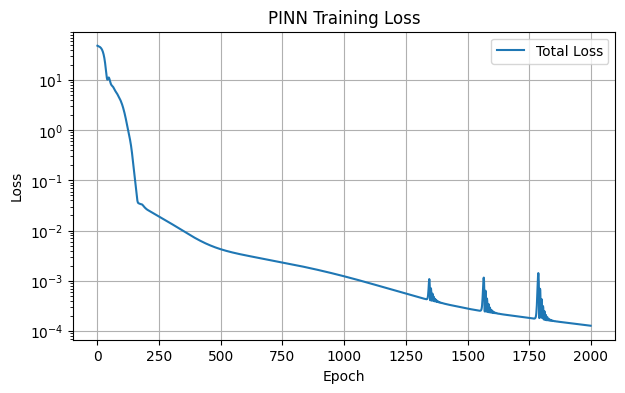

In [ ]:
plt.figure(figsize=(7, 4))

plt.semilogy(loss_history, label="Total Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

# Predict the solution using PINN.

In [ ]:
# Test points
x_test = np.linspace(-1.0, 1.0, 1000).reshape(-1, 1)

x_test = x_test.astype(np.float32)

# Convert to TensorFlow tensor
x_test_tf = tf.convert_to_tensor(x_test)

# PINN prediction
y_pred = call_model(model, x_test_tf)

# Convert TensorFlow tensor to NumPy
y_pred = y_pred.numpy()

print("Prediction shape:", y_pred.shape)

Prediction shape: (1000, 1)


In [ ]:
y_true = np.sin(np.pi * x_test)

Analytical vs PINN Plot

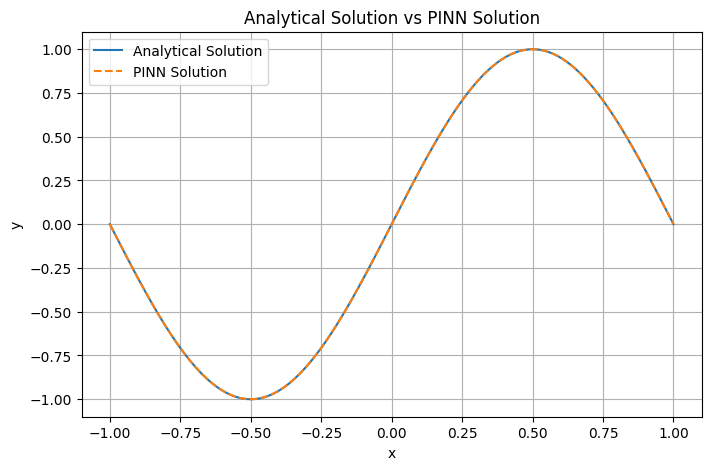

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(x_test, y_true, label="Analytical Solution")

plt.plot(x_test, y_pred, "--", label="PINN Solution")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Analytical Solution vs PINN Solution")

plt.legend()
plt.grid(True)

plt.show()

Let's calculate the numerical error.

In [ ]:
relative_l2_error = (np.linalg.norm(y_pred - y_true)/np.linalg.norm(y_true))

print("Relative L2 Error =",relative_l2_error)

Relative L2 Error = 0.00022888965


Boundary Condition Check

In [ ]:
boundary_prediction = call_model(model, x_bc)

print("Boundary x:")
print(x_bc.numpy())

print("\nExpected y:")
print(y_bc.numpy())

print("\nPINN predicted y:")
print(boundary_prediction.numpy())

Boundary x:
[[-1.]
 [ 1.]]

Expected y:
[[0.]
 [0.]]

PINN predicted y:
[[ 0.00029517]
 [-0.00023532]]


# PINN Check: PDE Residual

In [ ]:
x_residual = tf.linspace(-1.0, 1.0, 200)

x_residual = tf.reshape(x_residual, (-1, 1))

residual_values = pde(x_residual, model)

print("Mean absolute residual =", tf.reduce_mean(tf.abs(residual_values)).numpy())

print("Maximum absolute residual =", tf.reduce_max(tf.abs(residual_values)).numpy())

Mean absolute residual = 0.0077840458
Maximum absolute residual = 0.05899284


Residual Plot

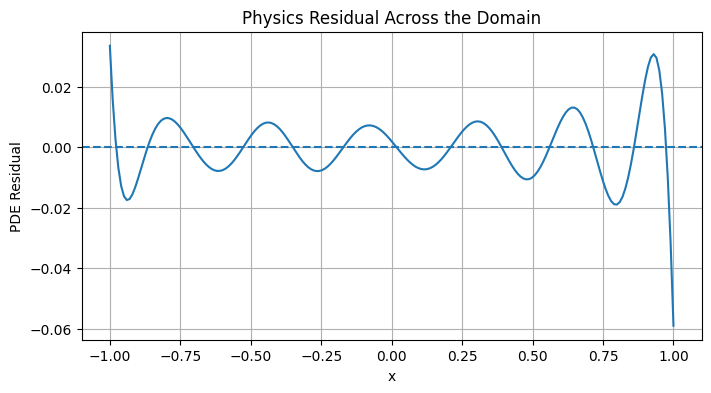

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(x_residual.numpy(), residual_values.numpy())

plt.axhline(0, linestyle="--")

plt.xlabel("x")
plt.ylabel("PDE Residual")

plt.title("Physics Residual Across the Domain")

plt.grid(True)

plt.show()